In [1]:
# CUADERNILLO COMPLETO — RED NEURONAL NHANES DEMO_L 2021-2023
# Clasificación binaria: predecir si una persona
# está por debajo de la línea de pobreza (INDFMPIR < 1.0)
# ============================================================

# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# PyTorch para construir y entrenar redes neuronales
import torch

# Para crear Dataset y DataLoader
from torch.utils.data import Dataset, DataLoader

# Librerías para manipulación de datos
import numpy as np
import pandas as pd

# Librería para gráficos
from matplotlib import pyplot as plt

# Barra de progreso
from tqdm import tqdm

# Métricas de evaluación
from sklearn.metrics import confusion_matrix, accuracy_score

print("Librerías cargadas correctamente.")

# ============================================================
# 2. DETECTAR GPU
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo utilizado:", device)

Librerías cargadas correctamente.
Dispositivo utilizado: cpu


In [3]:
import pyreadstat

data, meta = pyreadstat.read_xport(
    "DEMO_L.xpt",
    encoding="latin1"
)

print("Dataset cargado correctamente")
print(data.shape)
display(data.head())

Dataset cargado correctamente
(11933, 27)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,50055.450807,54374.463898,173.0,2.0,5.00
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,29087.450605,34084.721548,173.0,2.0,5.00
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,80062.674301,81196.277992,174.0,1.0,1.41
3,130381.0,12.0,2.0,2.0,5.0,NaN,5.0,7.0,1.0,71.0,...,2.0,2.0,2.0,3.0,NaN,38807.268902,55698.607106,182.0,2.0,1.53
4,130382.0,12.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,34.0,...,2.0,2.0,3.0,1.0,2.0,30607.519774,36434.146346,182.0,2.0,3.60


In [4]:
# ============================================================
# 5. EXPLORACIÓN INICIAL
# ============================================================

print("\nColumnas disponibles:")
print(list(data.columns))

print("\nValores nulos por columna:")
print(data.isnull().sum())

print("\nEstadísticas descriptivas de variables clave:")

display(
    data[['RIDAGEYR','DMDHHSIZ','INDFMPIR']].describe()
)


Columnas disponibles:
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4', 'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'DMDHHSIZ', 'DMDHRGND', 'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR']

Valores nulos por columna:
SEQN            0
SDDSRVYR        0
RIDSTATR        0
RIAGENDR        0
RIDAGEYR        0
RIDAGEMN    11556
RIDRETH1        0
RIDRETH3        0
RIDEXMON     3073
RIDEXAGM     9146
DMQMILIZ     3632
DMDBORN4       19
DMDYRUSR    10058
DMDEDUC2     4139
DMDMARTZ     4141
RIDEXPRG    10430
DMDHHSIZ        0
DMDHRGND     7818
DMDHRAGZ     7809
DMDHREDZ     8187
DMDHRMAZ     7913
DMDHSEDZ     9806
WTINT2YR        0
WTMEC2YR        0
SDMVSTRA        0
SDMVPSU         0
INDFMPIR     2041
dtype: int64

Estadísticas descriptivas de variables clave:


,RIDAGEYR,DMDHHSIZ,INDFMPIR
count,11933.000000,11933.000000,9892.000000
mean,38.317858,3.242772,2.708174
std,25.601990,1.699512,1.670119
min,0.000000,1.000000,0.000000
25%,13.000000,2.000000,1.180000
50%,37.000000,3.000000,2.500000
75%,62.000000,4.000000,4.500000
max,80.000000,7.000000,5.000000


In [5]:
# ============================================================
# 6. SELECCIÓN DE COLUMNAS RELEVANTES
# ============================================================

features = [

    'RIAGENDR',   # Género (1=Hombre, 2=Mujer)
    'RIDAGEYR',   # Edad en años
    'RIDRETH3',   # Raza / etnia
    'DMDBORN4',   # País de nacimiento
    'DMDEDUC2',   # Nivel educativo
    'DMDMARTZ',   # Estado civil
    'DMDHHSIZ',   # Tamaño del hogar

]

target = "INDFMPIR"

# Crear copia con solo columnas necesarias
df = data[features + [target]].copy()

print("Columnas seleccionadas:", df.shape)

Columnas seleccionadas: (11933, 8)


In [6]:
# ============================================================
# 7. LIMPIEZA DE DATOS
# ============================================================

# 7a. eliminar filas donde el target es nulo
df = df.dropna(subset=[target])

print("Filas después de eliminar nulos:", len(df))


# 7b. reemplazar valores especiales
for col in ['DMDEDUC2','DMDMARTZ','DMDBORN4']:

    df[col] = df[col].replace([7,9,77,99], np.nan)


print("Valores especiales convertidos a NaN")


# 7c. imputar valores faltantes

df['DMDEDUC2'] = df['DMDEDUC2'].fillna(
    df['DMDEDUC2'].median()
)

df['DMDMARTZ'] = df['DMDMARTZ'].fillna(
    df['DMDMARTZ'].mode()[0]
)

df['DMDBORN4'] = df['DMDBORN4'].fillna(
    df['DMDBORN4'].mode()[0]
)

print("Nulos imputados")

print(df.isnull().sum())

Filas después de eliminar nulos: 9892
Valores especiales convertidos a NaN
Nulos imputados
RIAGENDR    0
RIDAGEYR    0
RIDRETH3    0
DMDBORN4    0
DMDEDUC2    0
DMDMARTZ    0
DMDHHSIZ    0
INDFMPIR    0
dtype: int64


In [7]:
# ============================================================
# 8. CREAR VARIABLE OBJETIVO BINARIA
# ============================================================

# INDFMPIR < 1  -> pobreza

df["pobreza"] = (df[target] < 1.0).astype(int)

print("\nDistribución de clases:")
print(df["pobreza"].value_counts())

print("\nPorcentaje por clase:")
print(df["pobreza"].value_counts(normalize=True)*100)


Distribución de clases:
pobreza
0    7954
1    1938
Name: count, dtype: int64

Porcentaje por clase:
pobreza
0    80.408411
1    19.591589
Name: proportion, dtype: float64


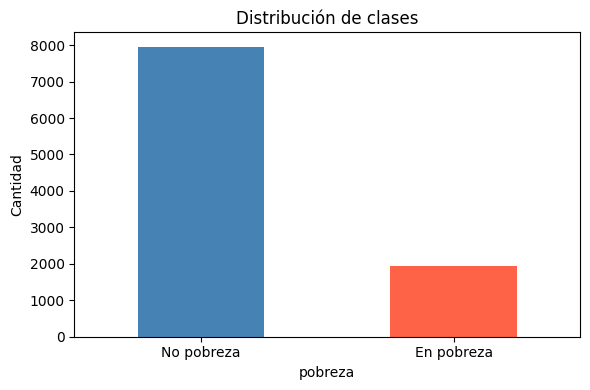

In [8]:
# ============================================================
# VISUALIZAR DISTRIBUCIÓN
# ============================================================

plt.figure(figsize=(6,4))

df["pobreza"].value_counts().plot(
    kind="bar",
    color=["steelblue","tomato"]
)

plt.xticks([0,1],["No pobreza","En pobreza"], rotation=0)

plt.title("Distribución de clases")

plt.ylabel("Cantidad")

plt.tight_layout()

plt.show()

In [10]:
# ============================================================
# 9. PREPARAR ARRAYS
# ============================================================

X = df[features].values
y = df["pobreza"].values

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (9892, 7)
Forma de y: (9892,)


In [11]:
# ============================================================
# 10. NORMALIZACIÓN
# ============================================================

def normalizar(X):

    mu = np.mean(X, axis=0)

    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


X_norm, mu, sigma = normalizar(X)

print("Media:", np.round(mu,3))

print("Desv:", np.round(sigma,3))

Media: [ 1.531 38.339  3.324  1.146  3.898  1.442  3.208]
Desv: [ 0.499 25.448  1.504  0.353  0.908  0.721  1.695]


In [12]:
# ============================================================
# 11. TRAIN / TEST
# ============================================================

split = int(len(X_norm)*0.8)

X_train = X_norm[:split]
y_train = y[:split]

X_test = X_norm[split:]
y_test = y[split:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (7913, 7)
Test: (1979, 7)
